In [27]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn


In [28]:
from pathlib import Path
import torch
import numpy as np

DATASET_ROOT = Path.home() / "Desktop" / "Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia"

train_dir = DATASET_ROOT / "Training"
test_dir = DATASET_ROOT / "Testing"

IMG_SIZE = 224
BATCH_SIZE = 16
VAL_RATIO = 0.2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [29]:
def find_dir_case_insensitive(parent, folder_name):
    parent = Path(parent)
    if not parent.exists():
        raise FileNotFoundError(f"Klasör bulunamadı: {parent}")
    for p in parent.iterdir():
        if p.is_dir() and p.name.lower() == folder_name.lower():
            return p
    raise FileNotFoundError(f"{parent} içinde '{folder_name}' klasörü bulunamadı.")

def list_images(folder):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([p for p in Path(folder).rglob("*") if p.suffix.lower() in valid_exts])

def check_image_file(img_path):
    try:
        with Image.open(img_path) as img:
            img.verify()
        return True, None
    except (UnidentifiedImageError, OSError, IOError) as e:
        return False, str(e)

def show_images(image_paths, title, n=6):
    n = min(n, len(image_paths))
    plt.figure(figsize=(12, 6))
    for i in range(n):
        img = Image.open(image_paths[i]).convert("L")
        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(image_paths[i].name)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [30]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"DATASET_ROOT bulunamadı:\n{DATASET_ROOT}")

train_dir = find_dir_case_insensitive(DATASET_ROOT, "Training")
test_dir  = find_dir_case_insensitive(DATASET_ROOT, "Testing")

train_normal_dir = find_dir_case_insensitive(train_dir, "normal")
train_pneumonia_dir = find_dir_case_insensitive(train_dir, "pneumonia")
test_normal_dir = find_dir_case_insensitive(test_dir, "normal")
test_pneumonia_dir = find_dir_case_insensitive(test_dir, "pneumonia")

print("DATASET_ROOT:", DATASET_ROOT)
print("Train:", train_dir)
print("Test :", test_dir)

DATASET_ROOT: /Users/eylul/Desktop/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia
Train: /Users/eylul/Desktop/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Training
Test : /Users/eylul/Desktop/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Testing


In [31]:
train_normal_imgs = list_images(train_normal_dir)
train_pneumonia_imgs = list_images(train_pneumonia_dir)
test_normal_imgs = list_images(test_normal_dir)
test_pneumonia_imgs = list_images(test_pneumonia_dir)

print("\n===== SINIF DAĞILIMI =====")
print("Train normal    :", len(train_normal_imgs))
print("Train pneumonia :", len(train_pneumonia_imgs))
print("Test normal     :", len(test_normal_imgs))
print("Test pneumonia  :", len(test_pneumonia_imgs))


===== SINIF DAĞILIMI =====
Train normal    : 1363
Train pneumonia : 1350
Test normal     : 321
Test pneumonia  : 320


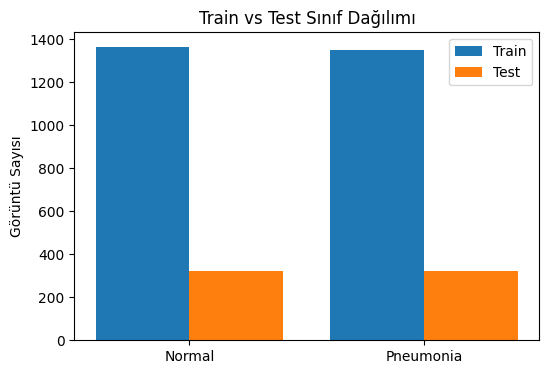

In [32]:
train_counts = [len(train_normal_imgs), len(train_pneumonia_imgs)]
test_counts = [len(test_normal_imgs), len(test_pneumonia_imgs)]

x = range(2)

plt.figure(figsize=(6,4))
plt.bar(x, train_counts, width=0.4, label="Train", align='center')
plt.bar([i+0.4 for i in x], test_counts, width=0.4, label="Test")

plt.xticks([i+0.2 for i in x], ["Normal", "Pneumonia"])
plt.ylabel("Görüntü Sayısı")
plt.title("Train vs Test Sınıf Dağılımı")
plt.legend()

plt.show()

In [33]:
all_images = (
    train_normal_imgs + train_pneumonia_imgs +
    test_normal_imgs + test_pneumonia_imgs
)

bad_files = []
for img_path in all_images:
    ok, err = check_image_file(img_path)
    if not ok:
        bad_files.append((img_path, err))

print("\n===== BOZUK DOSYA KONTROLÜ =====")
print("Toplam görüntü:", len(all_images))
print("Bozuk dosya sayısı:", len(bad_files))

if len(bad_files) > 0:
    print("İlk birkaç bozuk dosya:")
    for p, e in bad_files[:5]:
        print("-", p, "| Hata:", e)


===== BOZUK DOSYA KONTROLÜ =====
Toplam görüntü: 3354
Bozuk dosya sayısı: 0


In [34]:
records = []

for split_name, label_name, paths in [
    ("train", "normal", train_normal_imgs),
    ("train", "pneumonia", train_pneumonia_imgs),
    ("test", "normal", test_normal_imgs),
    ("test", "pneumonia", test_pneumonia_imgs),
]:
    for p in paths:
        try:
            with Image.open(p) as img:
                w, h = img.size
                mode = img.mode
            records.append({
                "split": split_name,
                "label": label_name,
                "path": str(p),
                "width": w,
                "height": h,
                "mode": mode,
                "ratio": round(w / h, 4) if h != 0 else None
            })
        except:
            pass

df = pd.DataFrame(records)

print("\n===== BOYUT ANALİZİ =====")
print(df[["width", "height"]].describe())

print("\nSınıfa göre boyut özeti:")
print(df.groupby(["split", "label"])[["width", "height"]].agg(["mean", "min", "max"]))

# En sık görülen boyutlar
top_sizes = (
    df.groupby(["width", "height"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
      .head(10)
)
print("\nEn sık görülen ilk 10 boyut:")
print(top_sizes)


===== BOYUT ANALİZİ =====
             width       height
count  3354.000000  3354.000000
mean   1116.492248   913.830054
std     469.676414   387.992685
min     256.000000   151.000000
25%     856.000000   515.500000
50%    1024.000000   964.000000
75%    1442.000000  1072.000000
max    2916.000000  2583.000000

Sınıfa göre boyut özeti:
                       width                  height           
                        mean  min   max         mean  min   max
split label                                                    
test  normal      903.962617  256  2514   850.978193  256  2264
      pneumonia  1369.315625  439  2890  1017.443750  151  2570
train normal      893.088775  256  2553   838.807043  256  2376
      pneumonia  1332.653333  438  2916   979.960000  173  2583

En sık görülen ilk 10 boyut:
      width  height  count
328    1024    1024    669
20      512     512    650
0       256     256     90
388    1072     648      4
1226   1612    1437      3
1290   1662    1276

In [35]:
print("Normal görüntü sayısı:", len(train_normal_imgs))
print("Pneumonia görüntü sayısı:", len(train_pneumonia_imgs))

Normal görüntü sayısı: 1363
Pneumonia görüntü sayısı: 1350



===== ÖRNEK GÖRÜNTÜLER =====


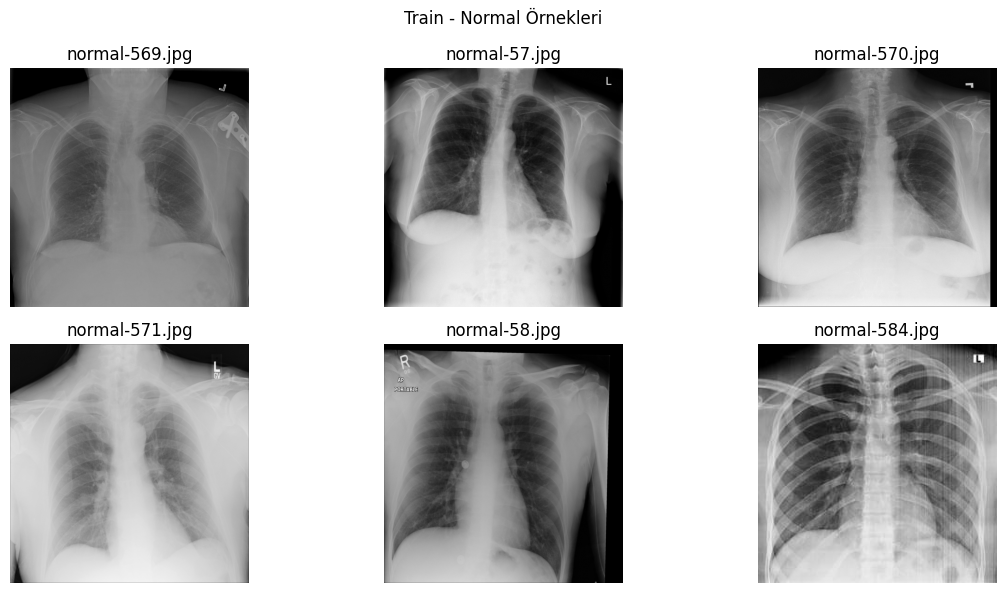

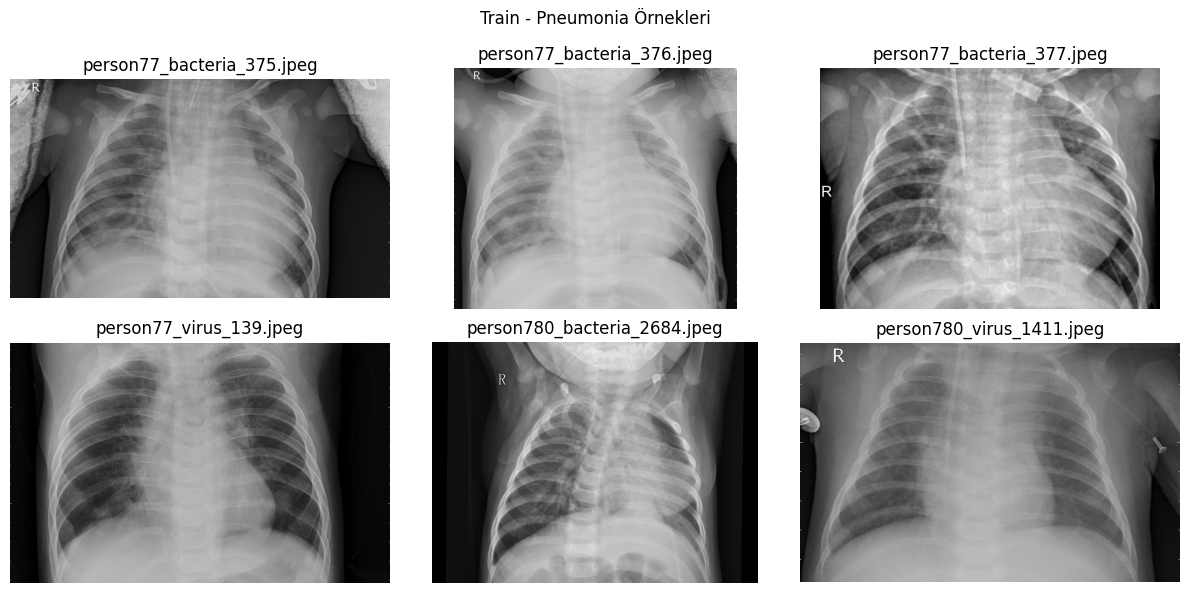

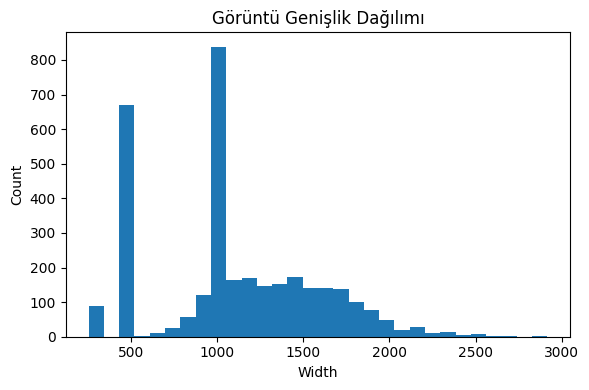

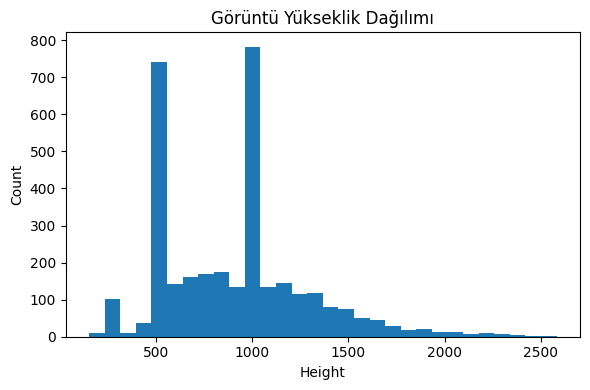

In [36]:
print("\n===== ÖRNEK GÖRÜNTÜLER =====")
show_images(train_normal_imgs, "Train - Normal Örnekleri", n=6)
show_images(train_pneumonia_imgs, "Train - Pneumonia Örnekleri", n=6)

# Boyut histogramı
plt.figure(figsize=(6, 4))
plt.hist(df["width"], bins=30)
plt.xlabel("Width")
plt.ylabel("Count")
plt.title("Görüntü Genişlik Dağılımı")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["height"], bins=30)
plt.xlabel("Height")
plt.ylabel("Count")
plt.title("Görüntü Yükseklik Dağılımı")
plt.tight_layout()
plt.show()

In [37]:
def compute_mean_std(image_paths, img_size=224, max_images=None):
    vals = []
    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()   # [1, H, W], 0-1 aralığı
    ])

    paths = image_paths if max_images is None else image_paths[:max_images]

    for p in paths:
        try:
            img = Image.open(p).convert("L")
            x = tfm(img)  # [1, H, W]
            vals.append(x)
        except:
            pass

    stacked = torch.stack(vals, dim=0)  # [N, 1, H, W]
    mean = stacked.mean().item()
    std = stacked.std().item()
    return mean, std
train_images_only = train_normal_imgs + train_pneumonia_imgs

mean_value, std_value = compute_mean_std(
    train_images_only,
    img_size=IMG_SIZE,
    max_images=300
)

print("\n===== PİKSEL İSTATİSTİĞİ =====")
print(f"Hesaplanan mean: {mean_value:.4f}")
print(f"Hesaplanan std : {std_value:.4f}")


===== PİKSEL İSTATİSTİĞİ =====
Hesaplanan mean: 0.5099
Hesaplanan std : 0.2546


In [38]:
std_value = max(std_value, 1e-6)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean_value], std=[std_value])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean_value], std=[std_value])
])

In [39]:
class ChestXrayDataset(Dataset):
    def __init__(self, split_dir, transform=None):
        self.split_dir = Path(split_dir)
        self.transform = transform

        self.normal_dir = find_dir_case_insensitive(self.split_dir, "normal")
        self.pneumonia_dir = find_dir_case_insensitive(self.split_dir, "pneumonia")

        self.samples = []

        for img_path in list_images(self.normal_dir):
            self.samples.append((img_path, 0))

        for img_path in list_images(self.pneumonia_dir):
            self.samples.append((img_path, 1))

        self.class_to_idx = {"normal": 0, "pneumonia": 1}
        self.idx_to_class = {0: "normal", 1: "pneumonia"}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [40]:
full_train_dataset = ChestXrayDataset(train_dir, transform=train_transform)
test_dataset = ChestXrayDataset(test_dir, transform=eval_transform)

val_size = int(len(full_train_dataset) * VAL_RATIO)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

full_train_eval_dataset = ChestXrayDataset(train_dir, transform=eval_transform)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

class SubsetWithTransform(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.base_dataset[self.indices[idx]]

train_dataset = SubsetWithTransform(full_train_dataset, train_indices)
val_dataset = SubsetWithTransform(full_train_eval_dataset, val_indices)

In [41]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("\n===== FINAL VERİ SAYILARI =====")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))


===== FINAL VERİ SAYILARI =====
Train: 2171
Val  : 542
Test : 641



Batch image shape: torch.Size([16, 1, 224, 224])
Batch label shape: torch.Size([16])
İlk 10 etiket: [0, 1, 0, 0, 1, 1, 0, 1, 1, 1]


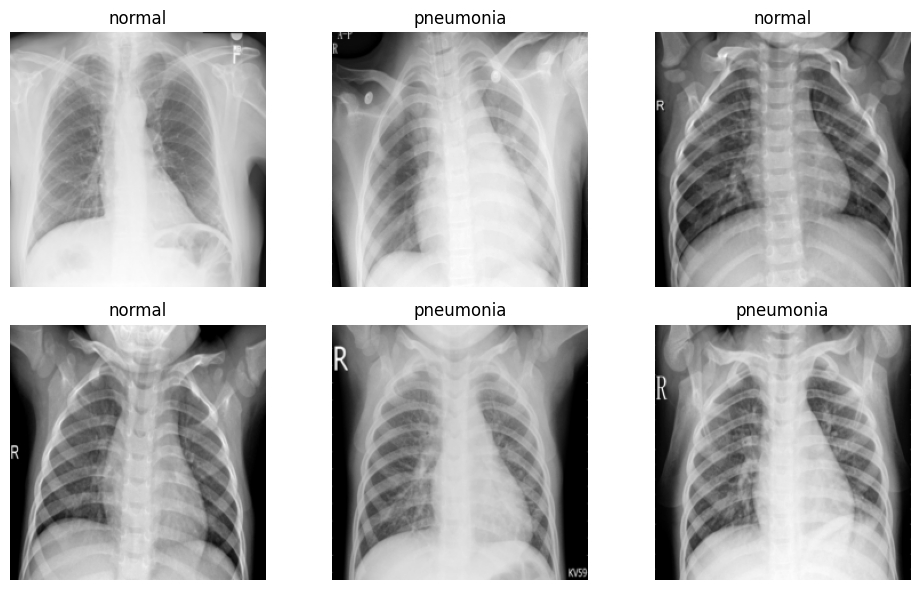

In [42]:
images, labels = next(iter(train_loader))
print("\nBatch image shape:", images.shape)   # örn [16, 1, 224, 224]
print("Batch label shape:", labels.shape)
print("İlk 10 etiket:", labels[:10].tolist())

# Normalize geri alma
images_vis = images.clone()
images_vis = images_vis * std_value + mean_value
images_vis = images_vis.clamp(0, 1)

plt.figure(figsize=(10, 6))
for i in range(min(6, len(images_vis))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_vis[i].squeeze().cpu().numpy(), cmap="gray")
    plt.title("normal" if labels[i].item() == 0 else "pneumonia")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [43]:
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[mean_value],
        std=[std_value]
    )
])

eval_transform_same = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[mean_value],
        std=[std_value]
    )
])

In [44]:
from pathlib import Path
from torch.utils.data import random_split

# Dataset yolu
DATASET_ROOT = Path("/Users/eylul/Desktop/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia")

train_dir = DATASET_ROOT / "Training"
test_dir = DATASET_ROOT / "Testing"

# Klasör kontrolü
assert train_dir.exists(), "Training klasörü bulunamadı"
assert test_dir.exists(), "Testing klasörü bulunamadı"

# Train dataset (split için transform yok)
full_dataset = ChestXrayDataset(train_dir, transform=None)

# Train / Validation split
train_size = int(len(full_dataset) * 0.8)
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

train_indices = train_subset.indices
val_indices = val_subset.indices

# Sprint 2 dataset (augmentation uygulanmış)
train_dataset_s2 = SubsetWithTransform(
    base_dataset=ChestXrayDataset(train_dir, transform=train_transform_aug),
    indices=train_indices
)

val_dataset_s2 = SubsetWithTransform(
    base_dataset=ChestXrayDataset(train_dir, transform=eval_transform_same),
    indices=val_indices
)

# Test dataset
test_dataset_s2 = ChestXrayDataset(test_dir, transform=eval_transform_same)

print("Sprint 2 train boyutu:", len(train_dataset_s2))
print("Sprint 2 val boyutu:", len(val_dataset_s2))
print("Sprint 2 test boyutu:", len(test_dataset_s2))

Sprint 2 train boyutu: 2170
Sprint 2 val boyutu: 543
Sprint 2 test boyutu: 641


In [45]:
train_loader_s2 = DataLoader(train_dataset_s2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_s2 = DataLoader(val_dataset_s2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_s2 = DataLoader(test_dataset_s2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader_s2))
print("Sprint 2 train batch image shape:", images.shape)
print("Sprint 2 train batch label shape:", labels.shape)

Sprint 2 train batch image shape: torch.Size([16, 1, 224, 224])
Sprint 2 train batch label shape: torch.Size([16])


In [46]:
train_labels = [
    train_dataset_s2.base_dataset.samples[i][1]
    for i in train_dataset_s2.indices
]

train_class_counts = np.bincount(train_labels, minlength=2)

print("Train sınıf sayıları:", train_class_counts)

class_weights = train_class_counts.sum() / (len(train_class_counts) * train_class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights:", class_weights)

Train sınıf sayıları: [1087 1083]
Class weights: tensor([0.9982, 1.0018])


In [47]:
# baseline model
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Baseline CNN hazır.")

Baseline CNN hazır.


In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan device:", device)

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

print("Baseline model, loss ve optimizer hazır.")

Kullanılan device: cpu
Baseline model, loss ve optimizer hazır.


In [49]:
#train fonksiyon
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0

    return avg_loss, acc, prec, rec, f1, auc, all_labels, all_preds, all_probs

In [51]:
num_epochs = 10
best_val_f1 = -1.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

print("Baseline eğitim ayarları hazır.")

Baseline eğitim ayarları hazır.


In [57]:
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1} başladı...")

    train_loss, train_acc = train_one_epoch(
        model, train_loader_s2, criterion, optimizer, device
    )

    print("Train kısmı bitti, şimdi validation başlıyor...")

    val_loss, val_acc, val_prec, val_rec, val_f1, val_auc, _, _, _ = evaluate(
        model, val_loader_s2, criterion, device
    )

    print("Validation bitti.")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_prec)
    history["val_recall"].append(val_rec)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f}")
    print(f"Val Recall:    {val_rec:.4f}")
    print(f"Val F1:        {val_f1:.4f}")
    print(f"Val AUC:       {val_auc:.4f}")
    print("-" * 50)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "baseline_cnn_best.pth")
        print("En iyi baseline model kaydedildi.")

Epoch 1 başladı...
Train kısmı bitti, şimdi validation başlıyor...
Validation bitti.
Epoch 1/10
Train Loss: 0.2233 | Train Acc: 0.8949
Val Loss:   0.1775 | Val Acc: 0.9190
Val Precision: 0.8729
Val Recall:    0.9775
Val F1:        0.9223
Val AUC:       0.9728
--------------------------------------------------
Epoch 2 başladı...
Train kısmı bitti, şimdi validation başlıyor...
Validation bitti.
Epoch 2/10
Train Loss: 0.2224 | Train Acc: 0.8977
Val Loss:   0.1947 | Val Acc: 0.9098
Val Precision: 0.8838
Val Recall:    0.9401
Val F1:        0.9111
Val AUC:       0.9745
--------------------------------------------------
Epoch 3 başladı...
Train kısmı bitti, şimdi validation başlıyor...
Validation bitti.
Epoch 3/10
Train Loss: 0.2034 | Train Acc: 0.9018
Val Loss:   0.1945 | Val Acc: 0.9116
Val Precision: 0.8687
Val Recall:    0.9663
Val F1:        0.9149
Val AUC:       0.9722
--------------------------------------------------
Epoch 4 başladı...
Train kısmı bitti, şimdi validation başlıyor...


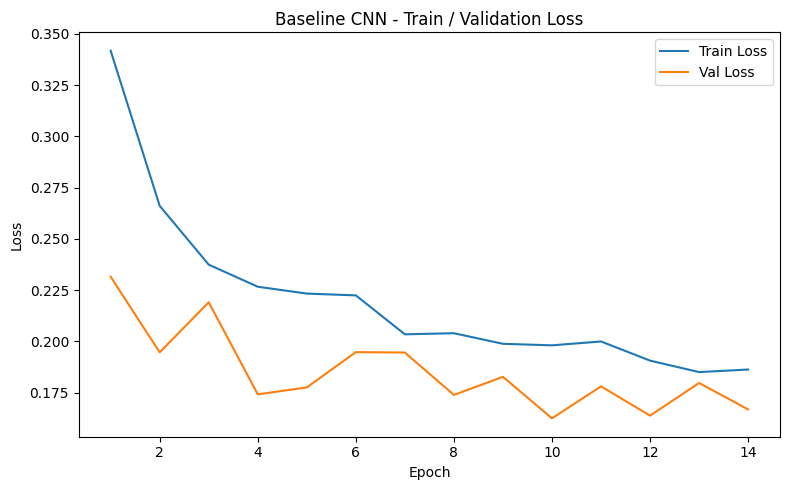

In [60]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Train / Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

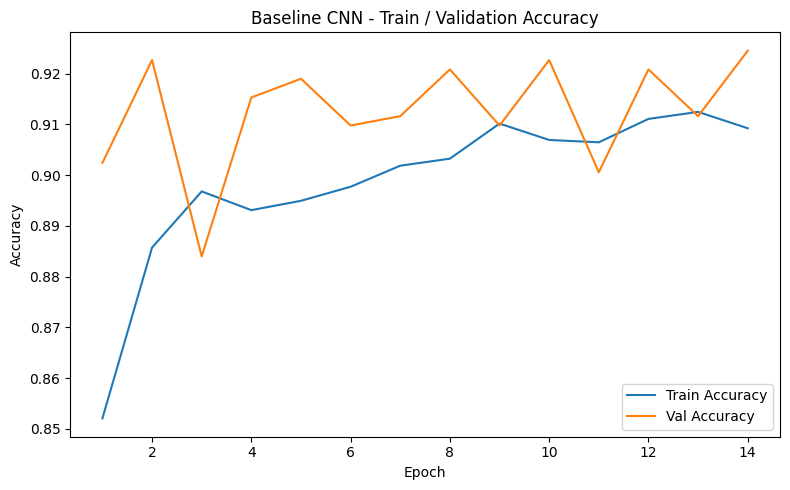

In [61]:
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Train / Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
best_model = BaselineCNN().to(device)

best_model.load_state_dict(
    torch.load("baseline_cnn_best.pth", map_location=device)
)

best_model.eval()

print("En iyi baseline model yüklendi.")

En iyi baseline model yüklendi.


In [68]:
test_loss, test_acc, test_prec, test_rec, test_f1, test_auc, y_true, y_pred, y_prob = evaluate(
    best_model, test_loader_s2, criterion, device
)

print("===== TEST SONUÇLARI =====")
print(f"Loss      : {test_loss:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"AUC       : {test_auc:.4f}")


===== TEST SONUÇLARI =====
Loss      : 0.1744
Accuracy  : 0.9173
Precision : 0.8638
Recall    : 0.9906
F1 Score  : 0.9229
AUC       : 0.9740


In [69]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pneumonia"],
    zero_division=0
))

Confusion Matrix:
[[271  50]
 [  3 317]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.84      0.91       321
   Pneumonia       0.86      0.99      0.92       320

    accuracy                           0.92       641
   macro avg       0.93      0.92      0.92       641
weighted avg       0.93      0.92      0.92       641



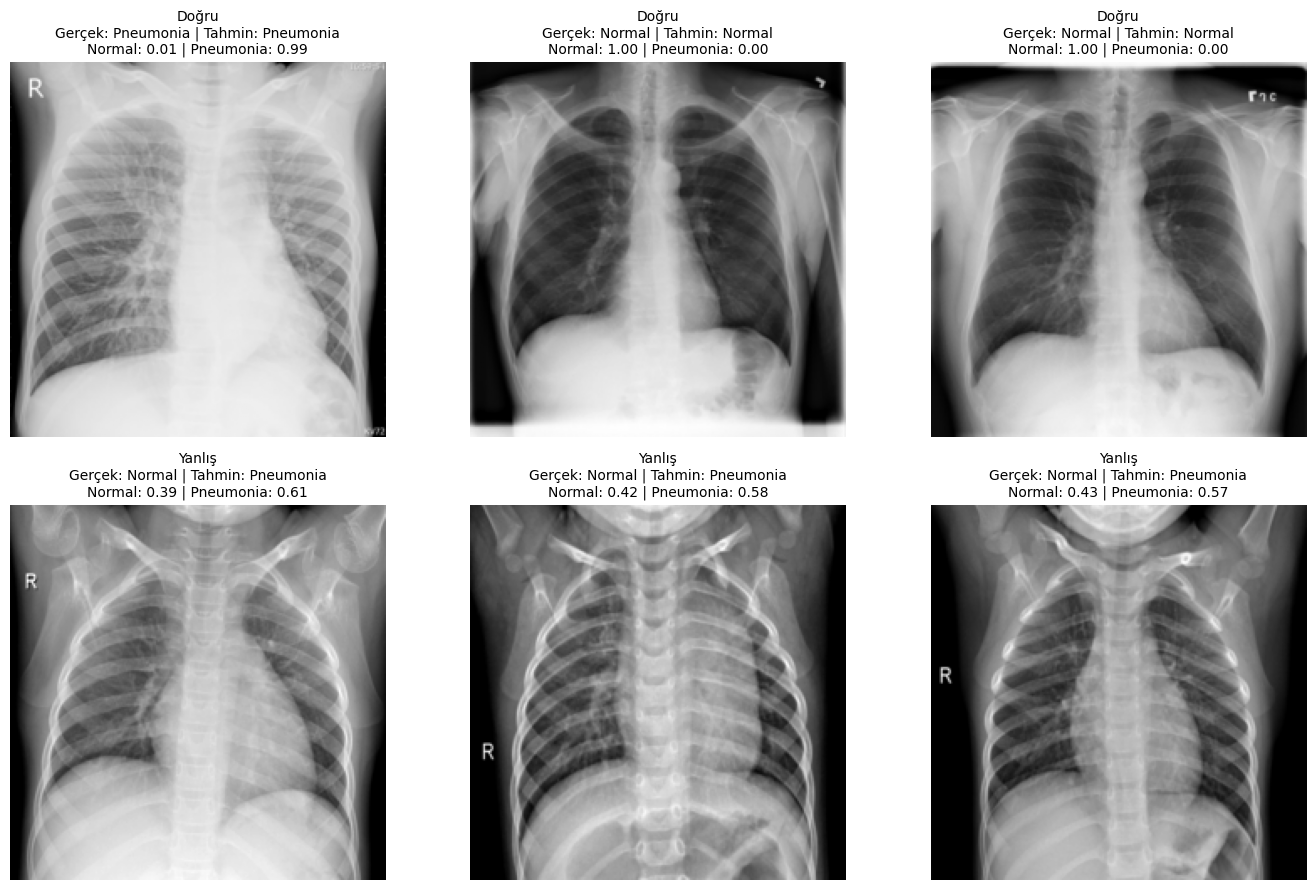

In [71]:
import random
import math
import matplotlib.pyplot as plt
import torch
import numpy as np

def denormalize(img_tensor, mean, std):
    mean = torch.tensor([mean]).view(-1, 1, 1)
    std = torch.tensor([std]).view(-1, 1, 1)
    return img_tensor * std + mean


def show_correct_and_wrong_predictions(model, dataset, device, num_correct=3, num_wrong=3):
    model.eval()

    class_names = {
        0: "Normal",
        1: "Pneumonia"
    }

    correct_samples = []
    wrong_samples = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)

            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)[0]

            pred = torch.argmax(probs).item()

            sample_info = {
                "idx": idx,
                "image": image.cpu(),
                "label": label,
                "pred": pred,
                "normal_prob": probs[0].item(),
                "pneumonia_prob": probs[1].item()
            }

            if pred == label:
                correct_samples.append(sample_info)
            else:
                wrong_samples.append(sample_info)

    selected_correct = random.sample(
        correct_samples,
        min(num_correct, len(correct_samples))
    )

    selected_wrong = random.sample(
        wrong_samples,
        min(num_wrong, len(wrong_samples))
    )

    selected_samples = selected_correct + selected_wrong

    cols = 3
    rows = math.ceil(len(selected_samples) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, selected_samples):
        image = sample["image"]
        label = sample["label"]
        pred = sample["pred"]

        img = denormalize(
            image,
            mean_value,
            std_value if std_value > 0 else 0.5
        )

        img = img.squeeze(0).clamp(0, 1).numpy()

        result_text = "Doğru" if pred == label else "Yanlış"

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"{result_text}\n"
            f"Gerçek: {class_names[label]} | Tahmin: {class_names[pred]}\n"
            f"Normal: {sample['normal_prob']:.2f} | Pneumonia: {sample['pneumonia_prob']:.2f}",
            fontsize=10
        )
        ax.axis("off")

    for ax in axes[len(selected_samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_correct_and_wrong_predictions(
    best_model,
    test_dataset_s2,
    device,
    num_correct=3,
    num_wrong=3
)